#### 1) Importing Necessary Libraries:

In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('horse.csv')

In [3]:
df.head()

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,extreme_pain,absent,severe,NaN,NaN,NaN,decreased,distend_large,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,mild_pain,absent,slight,NaN,NaN,NaN,absent,other,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,mild_pain,hypomotile,none,NaN,NaN,NaN,normal,normal,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,depressed,absent,severe,none,less_1_liter,5.0,decreased,NaN,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


In [4]:
df.shape

(299, 28)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   surgery                299 non-null    object 
 1   age                    299 non-null    object 
 2   hospital_number        299 non-null    int64  
 3   rectal_temp            239 non-null    float64
 4   pulse                  275 non-null    float64
 5   respiratory_rate       241 non-null    float64
 6   temp_of_extremities    243 non-null    object 
 7   peripheral_pulse       230 non-null    object 
 8   mucous_membrane        252 non-null    object 
 9   capillary_refill_time  267 non-null    object 
 10  pain                   244 non-null    object 
 11  peristalsis            255 non-null    object 
 12  abdominal_distention   243 non-null    object 
 13  nasogastric_tube       195 non-null    object 
 14  nasogastric_reflux     193 non-null    object 
 15  nasoga

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
hospital_number,299.0,1.087733e+06,1.532032e+06,518476.0,528904.0,530301.0,534736.00,5305629.0
rectal_temp,239.0,3.816862e+01,7.337444e-01,35.4,37.8,38.2,38.50,40.8
pulse,275.0,7.200000e+01,2.864622e+01,30.0,48.0,64.0,88.00,184.0
respiratory_rate,241.0,3.046058e+01,1.766610e+01,8.0,18.0,25.0,36.00,96.0
nasogastric_reflux_ph,53.0,4.707547e+00,1.982311e+00,1.0,3.0,5.0,6.50,7.5
packed_cell_volume,270.0,4.630741e+01,1.043674e+01,23.0,38.0,45.0,52.00,75.0
total_protein,266.0,2.427444e+01,2.736419e+01,3.3,6.5,7.5,56.75,89.0
abdomo_protein,101.0,3.039604e+00,1.967947e+00,0.1,2.0,2.3,3.90,10.1
lesion_1,299.0,3.659709e+03,5.408472e+03,0.0,2111.5,2322.0,3209.00,41110.0
lesion_2,299.0,9.052843e+01,6.506371e+02,0.0,0.0,0.0,0.00,7111.0


In [8]:
df['outcome'].value_counts()

outcome
lived         178
died           77
euthanized     44
Name: count, dtype: int64

- There are both Numeric and Categorical features in data.
- There are Missing Values in the dataset.

#### 3) Data Cleaning and Transformations:

In [9]:
# Missing Value Percentage:

df.isna().sum() / len(df) * 100

surgery                   0.000000
age                       0.000000
hospital_number           0.000000
rectal_temp              20.066890
pulse                     8.026756
respiratory_rate         19.397993
temp_of_extremities      18.729097
peripheral_pulse         23.076923
mucous_membrane          15.719064
capillary_refill_time    10.702341
pain                     18.394649
peristalsis              14.715719
abdominal_distention     18.729097
nasogastric_tube         34.782609
nasogastric_reflux       35.451505
nasogastric_reflux_ph    82.274247
rectal_exam_feces        34.113712
abdomen                  39.464883
packed_cell_volume        9.698997
total_protein            11.036789
abdomo_appearance        55.183946
abdomo_protein           66.220736
outcome                   0.000000
surgical_lesion           0.000000
lesion_1                  0.000000
lesion_2                  0.000000
lesion_3                  0.000000
cp_data                   0.000000
dtype: float64

- Some of the Features have more than 50% of Data Missing.
- For simplicity, we can drop this features.

In [14]:
df.drop(['nasogastric_reflux_ph', 'abdomo_appearance', 'abdomo_protein'], axis= 1, inplace= True)

In [15]:
df.shape

(299, 25)

In [16]:
df['hospital_number'].nunique()

283

- Hospital Number Seems to be Unique for most of the records and won't help in Survival Predictability.
- We can drop this feature too.

In [18]:
df.drop('hospital_number', axis= 1, inplace= True)

In [19]:
df.shape

(299, 24)

- We will go Feature by Feature now for Missing Value Imputations and Transformations:

In [20]:
df.columns

Index(['surgery', 'age', 'rectal_temp', 'pulse', 'respiratory_rate',
       'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane',
       'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention',
       'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces',
       'abdomen', 'packed_cell_volume', 'total_protein', 'outcome',
       'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data'],
      dtype='object')

##### 1) surgery:

In [21]:
df['surgery'].value_counts()

surgery
yes    180
no     119
Name: count, dtype: int64

In [22]:
df['surgery'].isna().sum()

np.int64(0)

- Surgery is a Nominal Categorical Variable with no Missing Values.
- Transformation: One hot encoding.

In [23]:
surgery_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 2) age:

In [25]:
df['age']

0      adult
1      adult
2      adult
3      young
4      adult
       ...  
294    adult
295    adult
296    adult
297    adult
298    adult
Name: age, Length: 299, dtype: object

In [26]:
df['age'].value_counts()

age
adult    275
young     24
Name: count, dtype: int64

In [27]:
df['age'].isna().sum()

np.int64(0)

- Age is a Nominal Categorical feature with no missing values.
- Transformation: One hot encoding.

In [171]:
age_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 3) rectal_temp:

In [30]:
df['rectal_temp']

0      38.5
1      39.2
2      38.3
3      39.1
4      37.3
       ... 
294     NaN
295    37.2
296    37.5
297    36.5
298    37.2
Name: rectal_temp, Length: 299, dtype: float64

In [31]:
df['rectal_temp'].isna().sum()

np.int64(60)

- Rectal Temp is a Numeric Continuous Variable and has Missing Values.

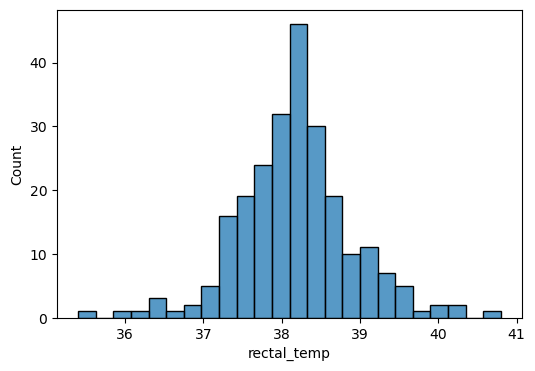

In [33]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'rectal_temp')
plt.show()

- Rectal temp has NOrmal Distribution.
- We can use Mean or Median to fill in Missing Values.
- Transformations: Imputation, Scaling.

In [36]:
rectemp_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler())
])

##### 4) pulse:

In [38]:
df['pulse']

0       66.0
1       88.0
2       40.0
3      164.0
4      104.0
       ...  
294    120.0
295     72.0
296     72.0
297    100.0
298     40.0
Name: pulse, Length: 299, dtype: float64

In [39]:
df['pulse'].isna().sum()

np.int64(24)

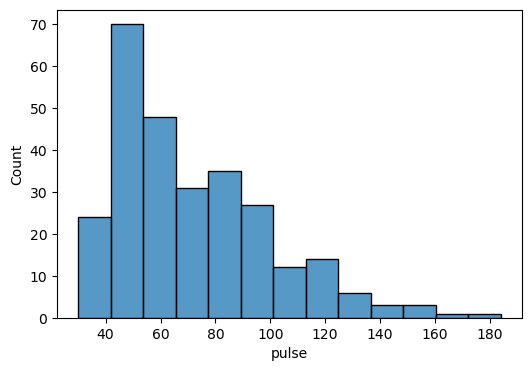

In [40]:
plt.figure(figsize=(6,4))
sns.histplot(data= df, x= 'pulse')
plt.show()

- Pulse is a Numeric Continuous Variable with a Right Tailed Distribution and Missing Values.
- Transformations: Imputation(with Median Value), Log Transformation, Scaling.

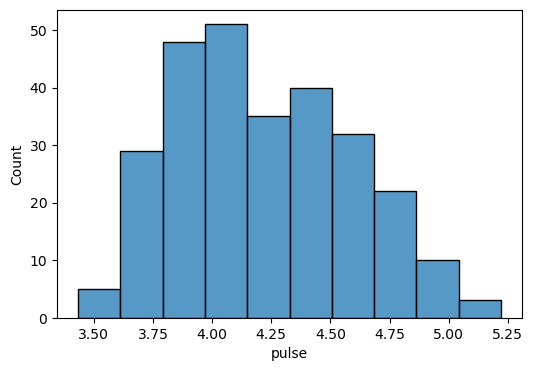

In [44]:
plt.figure(figsize=(6,4))
sns.histplot(data= df['pulse'].apply(np.log1p))
plt.show()

In [43]:
pulse_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

##### 5) respiratory_rate:

In [47]:
df['respiratory_rate']

0      28.0
1      20.0
2      24.0
3      84.0
4      35.0
       ... 
294    70.0
295    24.0
296    30.0
297    24.0
298    20.0
Name: respiratory_rate, Length: 299, dtype: float64

In [48]:
df['respiratory_rate'].isna().sum()

np.int64(58)

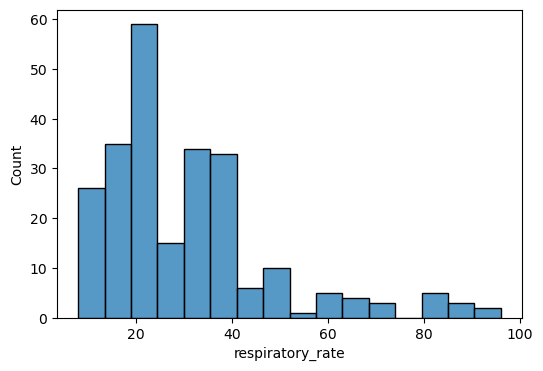

In [49]:
plt.figure(figsize=(6,4))
sns.histplot(data= df, x= 'respiratory_rate')
plt.show()

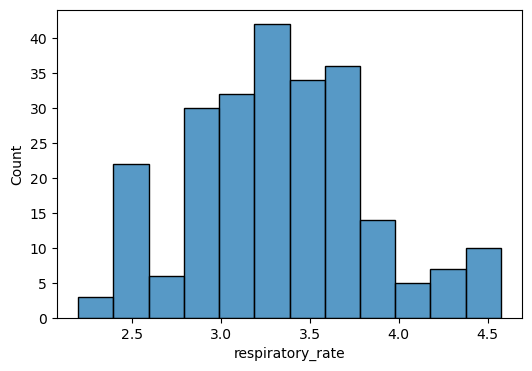

In [50]:
plt.figure(figsize=(6,4))
sns.histplot(data= df['respiratory_rate'].apply(np.log1p))
plt.show()

- Respiratory Rate is a Numeric Continuous Variable with Right Tailed Distribution and Missing values.
- Transformation: Imputation(with Median Value), Log Transforamtion, Scaling.

In [51]:
resprate_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaling', StandardScaler())
])

##### 6) temp_of_extremities:

In [53]:
df['temp_of_extremities']

0        cool
1         NaN
2      normal
3        cold
4         NaN
        ...  
294      cold
295      cool
296      cold
297      cool
298       NaN
Name: temp_of_extremities, Length: 299, dtype: object

In [54]:
df['temp_of_extremities'].value_counts()

temp_of_extremities
cool      108
normal     78
warm       30
cold       27
Name: count, dtype: int64

In [55]:
df['temp_of_extremities'].isna().sum()

np.int64(56)

- temp_of_extremities is a Nominal Categorical variable with Missing Values.
- Transformations: Imputation(with Mode), One Hot Encoding.

In [56]:
tempextr_pipelin = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 7) peripheral_pulse:

In [58]:
df['peripheral_pulse']

0        reduced
1            NaN
2         normal
3         normal
4            NaN
         ...    
294          NaN
295    increased
296      reduced
297      reduced
298          NaN
Name: peripheral_pulse, Length: 299, dtype: object

In [59]:
df['peripheral_pulse'].value_counts()

peripheral_pulse
normal       114
reduced      103
absent         8
increased      5
Name: count, dtype: int64

In [60]:
df['peripheral_pulse'].isna().sum()

np.int64(69)

- Peripheral Pulse is a Nominal Categorical feature with Missing Values.
- Transformations: Imputation(with Mode), One hot encoding.

In [61]:
peripulse_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 8) mucous_membrane:

In [63]:
df['mucous_membrane']

0                NaN
1      pale_cyanotic
2          pale_pink
3      dark_cyanotic
4      dark_cyanotic
           ...      
294    pale_cyanotic
295    pale_cyanotic
296    pale_cyanotic
297        pale_pink
298              NaN
Name: mucous_membrane, Length: 299, dtype: object

In [64]:
df['mucous_membrane'].value_counts()

mucous_membrane
normal_pink      79
pale_pink        57
pale_cyanotic    41
bright_pink      30
bright_red       25
dark_cyanotic    20
Name: count, dtype: int64

In [65]:
df['mucous_membrane'].isna().sum()

np.int64(47)

- Mucous Membrane is a Nominal Categorical Feature with Misisng values.
- Transformations: Imputation(with Mode), One hot encoding.

In [66]:
mucmemb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 9) capillary_refill_time:

In [68]:
df['capillary_refill_time']

0      more_3_sec
1      less_3_sec
2      less_3_sec
3      more_3_sec
4      more_3_sec
          ...    
294    more_3_sec
295    more_3_sec
296    less_3_sec
297    less_3_sec
298           NaN
Name: capillary_refill_time, Length: 299, dtype: object

In [69]:
df['capillary_refill_time'].value_counts()

capillary_refill_time
less_3_sec    187
more_3_sec     78
3               2
Name: count, dtype: int64

In [71]:
df['capillary_refill_time'].isna().sum()

np.int64(32)

- capillary_refill_time is an Ordinal Categorical Feature with Missing Values.
- Transformations: Imputation(with Mode), Ordinal Encoding, Scaling.

In [175]:
capref_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OrdinalEncoder(categories= [['less_3_sec','3','more_3_sec']])),
    ('scaler', StandardScaler())
])

##### 10) pain:

In [76]:
df['pain']

0      extreme_pain
1         mild_pain
2         mild_pain
3         depressed
4               NaN
           ...     
294       depressed
295     severe_pain
296     severe_pain
297       mild_pain
298             NaN
Name: pain, Length: 299, dtype: object

In [77]:
df['pain'].value_counts()

pain
mild_pain       67
depressed       59
extreme_pain    42
severe_pain     38
alert           38
Name: count, dtype: int64

In [78]:
df['pain'].isna().sum()

np.int64(55)

- pain is an Ordinal Categorical Variable with Missing Values.
- Transforamtions: Imputation(with Mode), Ordinal Encoding, Scaling.

In [176]:
pain_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OrdinalEncoder(categories= [['alert', 'depressed', 'mild_pain', 'severe_pain', 'extreme_pain']])),
    ('scaler', StandardScaler())
])

##### 11) peristalsis:

In [82]:
df['peristalsis']

0          absent
1          absent
2      hypomotile
3          absent
4             NaN
          ...    
294        absent
295    hypomotile
296        absent
297    hypomotile
298           NaN
Name: peristalsis, Length: 299, dtype: object

In [83]:
df['peristalsis'].value_counts()

peristalsis
hypomotile     127
absent          73
hypermotile     39
normal          16
Name: count, dtype: int64

In [84]:
df['peristalsis'].isna().sum()

np.int64(44)

- peristalsis is an Ordinal Categorical variable with Missing Values.
- Transformations: Imputation(with Mode), Ordinal Encoding, Scaling.

In [177]:
peristalsis_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OrdinalEncoder(categories= [['absent', 'hypomotile', 'normal', 'hypermotile']])),
    ('scaler', StandardScaler())
])

In [86]:
df.columns

Index(['surgery', 'age', 'rectal_temp', 'pulse', 'respiratory_rate',
       'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane',
       'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention',
       'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces',
       'abdomen', 'packed_cell_volume', 'total_protein', 'outcome',
       'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data'],
      dtype='object')

##### 12) abdominal_distention:

In [87]:
df['abdominal_distention']

0        severe
1        slight
2          none
3        severe
4           NaN
         ...   
294         NaN
295    moderate
296    moderate
297    moderate
298         NaN
Name: abdominal_distention, Length: 299, dtype: object

In [88]:
df['abdominal_distention'].value_counts()

abdominal_distention
none        75
slight      65
moderate    65
severe      38
Name: count, dtype: int64

In [89]:
df['abdominal_distention'].isna().sum()

np.int64(56)

- abdominal_distention is an Ordinal Categorical Variable.
- Transformations: Imputation(with Mode), Ordinal Encoding, Scaling.

In [178]:
abdodist_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OrdinalEncoder(categories= [['none', 'slight', 'moderate', 'severe']])),
    ('scaler', StandardScaler())
])

In [91]:
df.columns

Index(['surgery', 'age', 'rectal_temp', 'pulse', 'respiratory_rate',
       'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane',
       'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention',
       'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces',
       'abdomen', 'packed_cell_volume', 'total_protein', 'outcome',
       'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data'],
      dtype='object')

##### 13) nasogastric_tube:

In [92]:
df['nasogastric_tube']

0              NaN
1              NaN
2              NaN
3             none
4              NaN
          ...     
294            NaN
295    significant
296         slight
297    significant
298            NaN
Name: nasogastric_tube, Length: 299, dtype: object

In [93]:
df['nasogastric_tube'].value_counts()

nasogastric_tube
slight         101
none            71
significant     23
Name: count, dtype: int64

In [94]:
df['nasogastric_tube'].isna().sum()

np.int64(104)

- nasogastric_tube is an Ordinal Categorical Variable with Missing values.
- Transformations: Imputation(with Mode), Ordinal Encoding, Scaling.

In [179]:
nasotube_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OrdinalEncoder(categories= [['none', 'slight', 'significant']])),
    ('scaler', StandardScaler())
])

##### 14) nasogastric_reflux:

In [97]:
df['nasogastric_reflux']

0               NaN
1               NaN
2               NaN
3      less_1_liter
4               NaN
           ...     
294             NaN
295            none
296            none
297            none
298             NaN
Name: nasogastric_reflux, Length: 299, dtype: object

In [98]:
df['nasogastric_reflux'].value_counts()

nasogastric_reflux
none            119
more_1_liter     39
less_1_liter     35
Name: count, dtype: int64

In [99]:
df['nasogastric_reflux'].isna().sum()

np.int64(106)

- nasogastric_reflux is an Ordinal Categorical Variable with missing values.
- Transformations: Imputation(with Mode), Ordinal Encoding, Scaling.

In [180]:
nasoref_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OrdinalEncoder(categories= [['none', 'less_1_liter', 'more_1_liter']])),
    ('scaler', StandardScaler())
])

In [101]:
df.columns

Index(['surgery', 'age', 'rectal_temp', 'pulse', 'respiratory_rate',
       'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane',
       'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention',
       'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces',
       'abdomen', 'packed_cell_volume', 'total_protein', 'outcome',
       'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data'],
      dtype='object')

##### 15) rectal_exam_feces:

In [102]:
df['rectal_exam_feces']

0      decreased
1         absent
2         normal
3      decreased
4            NaN
         ...    
294          NaN
295       absent
296    decreased
297       absent
298       absent
Name: rectal_exam_feces, Length: 299, dtype: object

In [103]:
df['rectal_exam_feces'].value_counts()

rectal_exam_feces
absent       79
normal       57
decreased    48
increased    13
Name: count, dtype: int64

In [104]:
df['rectal_exam_feces'].isna().sum()

np.int64(102)

- rectal_exam_feces is an Ordinal Categorical Variable with Missing Values.
- Transformations: Imputation(with Mode), Ordinal Encoding, Scaling.

In [181]:
recexf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OrdinalEncoder(categories= [['absent', 'decreased', 'normal', 'increased']])),
    ('scaler', StandardScaler())
])

In [106]:
df.columns

Index(['surgery', 'age', 'rectal_temp', 'pulse', 'respiratory_rate',
       'temp_of_extremities', 'peripheral_pulse', 'mucous_membrane',
       'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distention',
       'nasogastric_tube', 'nasogastric_reflux', 'rectal_exam_feces',
       'abdomen', 'packed_cell_volume', 'total_protein', 'outcome',
       'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3', 'cp_data'],
      dtype='object')

##### 16) abdomen:

In [107]:
df['abdomen']

0      distend_large
1              other
2             normal
3                NaN
4                NaN
           ...      
294    distend_large
295    distend_small
296    distend_large
297    distend_small
298           normal
Name: abdomen, Length: 299, dtype: object

In [108]:
df['abdomen'].value_counts()

abdomen
distend_large    78
distend_small    43
normal           28
other            19
firm             13
Name: count, dtype: int64

In [109]:
df['abdomen'].isna().sum()

np.int64(118)

- abdomen is a Nominal Categorical Variable with Missing Values.
- Transformartions: Imputation(with Mode), One Hot Encoding.

In [110]:
abdomen_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 17) packed_cell_volume:

In [112]:
df['packed_cell_volume']

0      45.0
1      50.0
2      33.0
3      48.0
4      74.0
       ... 
294    55.0
295    44.0
296    60.0
297    50.0
298    36.0
Name: packed_cell_volume, Length: 299, dtype: float64

In [113]:
df['packed_cell_volume'].isna().sum()

np.int64(29)

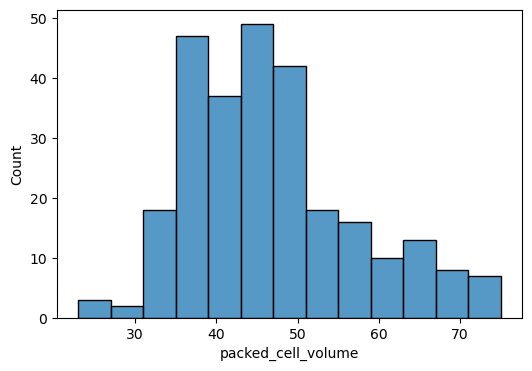

In [114]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'packed_cell_volume')
plt.show()

- packed_cell_volume is a Numeric Continuous Varibale with Missing values.
- Transformations: Imputation(with Median), Scaling.

In [115]:
cellvol_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler())
])

##### 18) total_protein:

In [117]:
df['total_protein']

0       8.4
1      85.0
2       6.7
3       7.2
4       7.4
       ... 
294    65.0
295     NaN
296     6.8
297     6.0
298    62.0
Name: total_protein, Length: 299, dtype: float64

In [118]:
df['total_protein'].isna().sum()

np.int64(33)

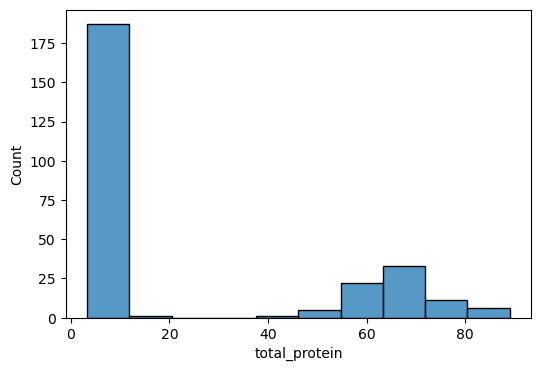

In [119]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'total_protein')
plt.show()

- total_protein is a Numeric Continuous Variable with Missing Values.
- The distribution is Highly Skewed and Bimodal, with data clustered at two end of distribution.
- As we are going to Use Decision Tree and Random Forest, which are less sensitive to skweness and lack of normalization, we can use the feature as is.
- Transformations: Imputation(with Median), Scaling.

In [127]:
protein_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler())
])

##### 19) outcome (Target Variable):

In [131]:
df['outcome'].value_counts()

outcome
lived         178
died           77
euthanized     44
Name: count, dtype: int64

- We have Multiclass Target Variable.

##### 20) surgical_lesion:

In [133]:
df['surgical_lesion']

0       no
1       no
2       no
3      yes
4       no
      ... 
294     no
295    yes
296    yes
297    yes
298     no
Name: surgical_lesion, Length: 299, dtype: object

In [134]:
df['surgical_lesion'].value_counts()

surgical_lesion
yes    190
no     109
Name: count, dtype: int64

In [135]:
df['surgical_lesion'].isna().sum()

np.int64(0)

- surgical_lesion is a Nominal Categorical variable with no missing values.
- Transformation: One hot encoding.

In [136]:
surles_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 21) lesion_1:

In [138]:
df['lesion_1']

0      11300
1       2208
2          0
3       2208
4       4300
       ...  
294     3205
295     2208
296     3205
297     2208
298     6112
Name: lesion_1, Length: 299, dtype: int64

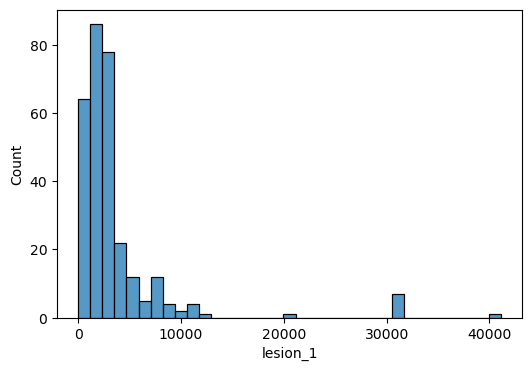

In [140]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'lesion_1')
plt.show()

In [147]:
df['lesion_1'].isna().sum()

np.int64(0)

- lesion_1 is a Numeric Continuous  Varibale with no Missing Values.
- Distribution is highly skewed.
- We will use the feature as is, as we are using tree based models.
- Transformations: Scaling

In [148]:
lesion1_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

##### 22) lesion_2:

In [150]:
df['lesion_2']

0      0
1      0
2      0
3      0
4      0
      ..
294    0
295    0
296    0
297    0
298    0
Name: lesion_2, Length: 299, dtype: int64

In [151]:
df['lesion_2'].value_counts()

lesion_2
0       292
3111      3
1400      1
7111      1
6112      1
3112      1
Name: count, dtype: int64

In [152]:
df['lesion_2'].isna().sum()

np.int64(0)

- lesion_2 seems to be sparse categorical or nominal variable where the vast majority of entries fall into a single category (or code), and the remaining categories are extremely rare.
- We will change the feature into 0: No second lesion, 1: Second lesion is present, and use One hot encoding after.

In [156]:
df['lesion_2_present']= np.where(df['lesion_2'] == 0, 0, 1)

In [157]:
df.drop('lesion_2', axis= 1, inplace= True) # Dropping Original Feature.

In [158]:
df['lesion_2_present'].value_counts()

lesion_2_present
0    292
1      7
Name: count, dtype: int64

In [159]:
lesion2_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 23) lesion_3:

In [161]:
df['lesion_3'].value_counts()

lesion_3
0       298
2209      1
Name: count, dtype: int64

In [162]:
df['lesion_3'].isna().sum()

np.int64(0)

- lesion_3 seems to be sparse categorical or nominal variable where the vast majority of entries fall into a single category (or code), and the remaining categories are extremely rare.
- We will change the feature into 0: No third lesion, 1: Third lesion is present, and use One hot encoding after.

In [163]:
df['lesion_3_present']= np.where(df['lesion_3'] == 0, 0, 1)
df.drop('lesion_3', axis= 1, inplace= True) # Dropping Original Feature.
df['lesion_3_present'].value_counts()

lesion_3_present
0    298
1      1
Name: count, dtype: int64

In [164]:
lesion3_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 24) cp_data:

In [166]:
df['cp_data']

0       no
1       no
2      yes
3      yes
4       no
      ... 
294     no
295    yes
296     no
297    yes
298     no
Name: cp_data, Length: 299, dtype: object

In [167]:
df['cp_data'].value_counts()

cp_data
no     200
yes     99
Name: count, dtype: int64

In [168]:
df['cp_data'].isna().sum()

np.int64(0)

- cp_data is a Nominal Categorical feature with no missing values.
- Transformations: One Hot Encoding.

In [169]:
cpd_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

#### 4) Final Column Transformer:

In [182]:
preprocessor = ColumnTransformer([
    ('surgery', surgery_pipeline, ['surgery']),
    ('age', age_pipeline, ['age']),
    ('rectal_temp', rectemp_pipeline, ['rectal_temp']),
    ('pulse', pulse_pipeline, ['pulse']),
    ('respiratory_rate', resprate_pipeline, ['respiratory_rate']),
    ('temp_of_extremities', tempextr_pipelin, ['temp_of_extremities']),
    ('peripheral_pulse', peripulse_pipeline, ['peripheral_pulse']),
    ('mucous_membrane', mucmemb_pipeline, ['mucous_membrane']),
    ('capillary_refill_time', capref_pipeline, ['capillary_refill_time']),
    ('pain', pain_pipeline, ['pain']),
    ('peristalsis', peristalsis_pipeline, ['peristalsis']),
    ('abdominal_distention', abdodist_pipeline, ['abdominal_distention']),
    ('nasogastric_tube', nasotube_pipeline, ['nasogastric_tube']),
    ('nasogastric_reflux', nasoref_pipeline, ['nasogastric_reflux']),
    ('rectal_exam_feces', recexf_pipeline, ['rectal_exam_feces']),
    ('abdomen', abdomen_pipeline, ['abdomen']),
    ('packed_cell_volume', cellvol_pipeline, ['packed_cell_volume']),
    ('total_protein', protein_pipeline, ['total_protein']),
    ('surgical_lesion', surles_pipeline, ['surgical_lesion']),
    ('lesion_1', lesion1_pipeline, ['lesion_1']),
    ('lesion_2_present', lesion2_pipeline, ['lesion_2_present']),
    ('lesion_3_present', lesion3_pipeline, ['lesion_3_present']),
    ('cp_data', cpd_pipeline, ['cp_data'])
], 
remainder= 'passthrough')

#### 5) Train Test Split:

In [185]:
X = df.drop('outcome', axis= 1) # Features
y = df['outcome'] # Target

In [186]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [187]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(239, 23)
(60, 23)
(239,)
(60,)


#### 6) Grid Search on Decision Tree:

In [189]:
dt_pipeline = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', DecisionTreeClassifier())
])

In [191]:
param_dict = {'Model__criterion': ['gini', 'entropy'],
             'Model__max_depth': [2, 5, 10, None],
             'Model__min_samples_split': [2, 5, 10, 20]
             }

grid_dt_model = GridSearchCV(estimator= dt_pipeline,
                            param_grid= param_dict,
                            cv= 10)

In [192]:
# Fitting Grid Model:

grid_dt_model.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'Model__criterion': ['gini', 'entropy'], 'Model__max_depth': [2, 5, ...], 'Model__min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('surgery', ...), ('age', ...), ...]"


In [194]:
# Best Estimator and Parameters According to Grid Search:

print(grid_dt_model.best_score_)
print(grid_dt_model.best_params_)

0.6606884057971014
{'Model__criterion': 'entropy', 'Model__max_depth': 10, 'Model__min_samples_split': 20}


In [195]:
# Predictions Using BEst Estimator from Grid Model:

y_pred = grid_dt_model.predict(X_test)

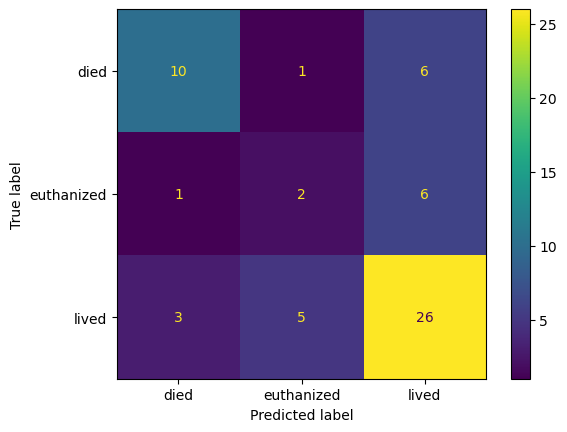

In [196]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= grid_dt_model.classes_)
disp.plot()
plt.show()

In [197]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        died       0.71      0.59      0.65        17
  euthanized       0.25      0.22      0.24         9
       lived       0.68      0.76      0.72        34

    accuracy                           0.63        60
   macro avg       0.55      0.53      0.53        60
weighted avg       0.63      0.63      0.63        60



In [206]:
# Grid Search Results:

pd.DataFrame(grid_dt_model.cv_results_)[['params', 'mean_test_score', 'rank_test_score']].sort_values(by= 'rank_test_score', ascending= True)

,params,mean_test_score,rank_test_score
31,"{'Model__criterion': 'entropy', 'Model__max_de...",0.660688,1
27,"{'Model__criterion': 'entropy', 'Model__max_de...",0.660688,1
12,"{'Model__criterion': 'gini', 'Model__max_depth...",0.648551,3
23,"{'Model__criterion': 'entropy', 'Model__max_de...",0.648551,4
13,"{'Model__criterion': 'gini', 'Model__max_depth...",0.640217,5
28,"{'Model__criterion': 'entropy', 'Model__max_de...",0.639855,6
24,"{'Model__criterion': 'entropy', 'Model__max_de...",0.639674,7
22,"{'Model__criterion': 'entropy', 'Model__max_de...",0.636051,8
20,"{'Model__criterion': 'entropy', 'Model__max_de...",0.631884,9
5,"{'Model__criterion': 'gini', 'Model__max_depth...",0.631522,10


#### 7) Grid Search on Random Forest Classifier:

In [208]:
rf_pipeline = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', RandomForestClassifier())
])

In [211]:
param_dict = {'Model__n_estimators': [5, 10, 25, 50, 100, 200, 500],
             'Model__criterion': ['gini', 'entropy'],
             'Model__max_depth': [2, 5, 10, 25, 50, None],
             'Model__bootstrap': [True, False],
             'Model__oob_score': [True, False]}

grid_rf_model = GridSearchCV(estimator= rf_pipeline,
                            param_grid= param_dict,
                            cv= 10)

In [ ]:
# Fitting the Model:

grid_rf_model.fit(X_train, y_train)

In [ ]:
# Best Estimator and Parameters According to Grid Search:

print(grid_rf_model.best_score_)
print(grid_rf_model.best_params_)

In [ ]:
# Predictions Using BEst Estimator from Grid Model:

y_pred = grid_rf_model.predict(X_test)

In [ ]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= grid_dt_model.classes_)
disp.plot()
plt.show()

In [ ]:
# Classification Report:

print(classification_report(y_test, y_pred))

In [ ]:
# Grid Search Results:

pd.DataFrame(grid_rf_model.cv_results_)[['params', 'mean_test_score', 'rank_test_score']].sort_values(by= 'rank_test_score', ascending= True)